# Visualização da Escala Ordinal de Notas à Imprensa do MRE

Este notebook gera visualizações gráficas a partir do resultado da **avaliação ordinal por LLM**:

`resultados/escalas-ordinais/escala-ordinal-llm-2026-09-01.json`

**Escala (1 a 5):** Soberania Digital ↔ Baixa Intervenção Estatal

| Nota | Descrição |
|------|-----------|
| 1 | Soberania Digital |
| 2 | Predominantemente Soberanista |
| 3 | Modelo Misto |
| 4 | Predominantemente Liberal |
| 5 | Baixa Intervenção Estatal |

As configurações de cores (`cores_escala`) podem ser ajustadas para refletir o gradiente da escala.


In [6]:
import json
import datetime as dt
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Caminho do arquivo de dados (escala ordinal por LLM)
ARQUIVO = "/workspaces/governanca-digital_mre/agente-classificador-notas-LLM/resultados/escalas-ordinais/escala-ordinal-llm-2026-09-01.json"

with open(ARQUIVO, encoding="utf-8") as f:
    dados = json.load(f)

print(f"Total de notas carregadas: {len(dados)}")
print(f"Colunas: {list(dados[0].keys())}")

# Ordem e rótulos da escala
ORDENS = [1, 2, 3, 4, 5]
ROTULOS = {
    1: "1 - Soberania Digital",
    2: "2 - Pred. Soberanista",
    3: "3 - Modelo Misto",
    4: "4 - Pred. Liberal",
    5: "5 - Baixa Intervenção",
}

# Cores: gradiente do polo soberanista (azul) ao polo liberal (vermelho/laranja)
cores_escala = ["#1f4e79", "#2e75b6", "#bf9000", "#c55a11", "#a62019"]
cmap = LinearSegmentedColormap.from_list("escala", cores_escala, N=5)

plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 11})


Total de notas carregadas: 169
Colunas: ['titulo', 'data', 'link', 'Nota_Escala', 'Descricao_Nota', 'Justificativa', 'Passagens_Relevantes']


## 1. Distribuição da Nota Escala (LLM)

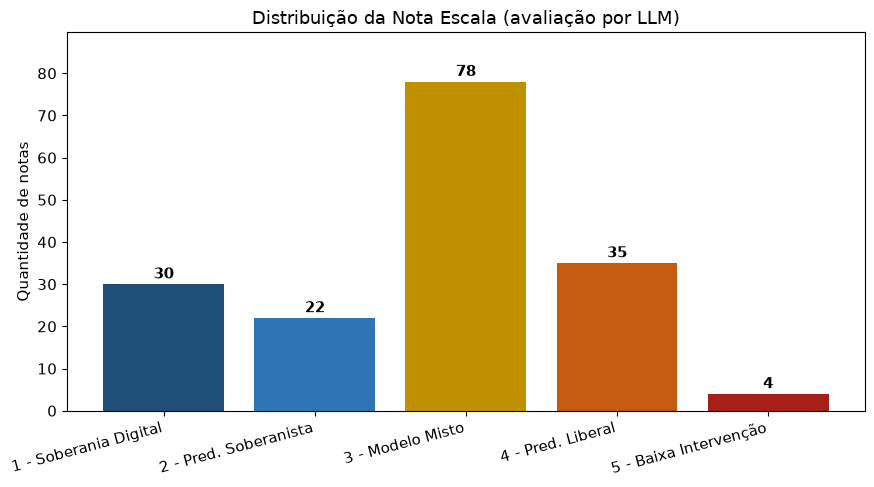

In [7]:
cont = Counter(int(d["Nota_Escala"]) for d in dados)
vals = [cont.get(k, 0) for k in ORDENS]

fig, ax = plt.subplots()
bars = ax.bar([ROTULOS[k] for k in ORDENS], vals, color=cores_escala)
ax.set_title("Distribuição da Nota Escala (avaliação por LLM)")
ax.set_ylabel("Quantidade de notas")
ax.set_ylim(0, max(vals) * 1.15)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, str(v), ha="center", va="bottom", fontweight="bold")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 2. Evolução Temporal da Nota Média

A nota média é calculada ano a ano a partir da `Nota_Escala`, revelando tendências ao longo do tempo no posicionamento das notas à imprensa.

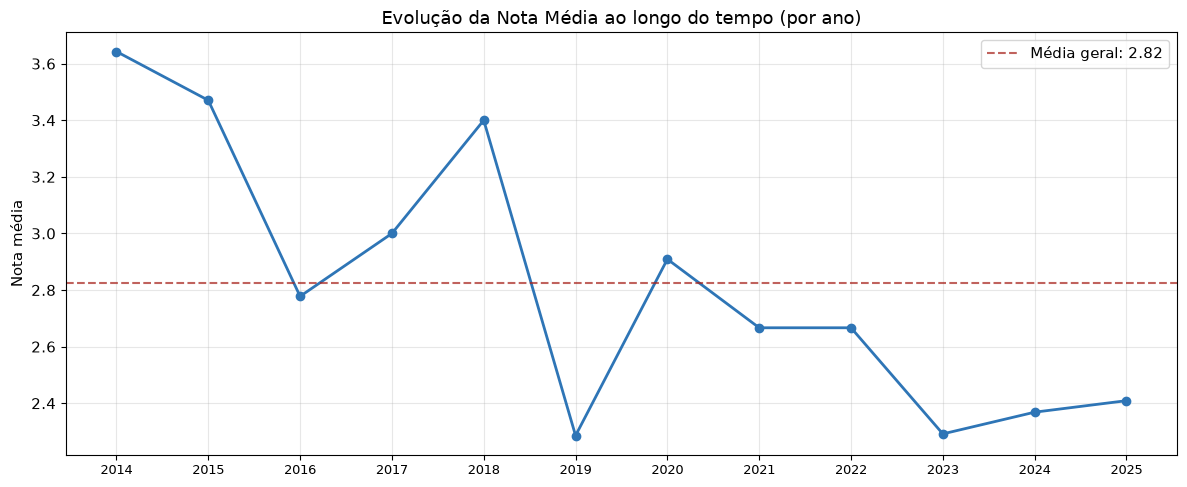

In [8]:
def parse_data(s):
    try:
        return dt.datetime.strptime(s, "%d/%m/%Y")
    except Exception:
        return None

series = defaultdict(list)
for d in dados:
    dt_obj = parse_data(d["data"])
    if dt_obj is None:
        continue
    chave = dt_obj.year
    series[chave].append(int(d["Nota_Escala"]))

if series:
    anos_med = sorted(series.keys())
    medias = [np.mean(series[a]) for a in anos_med]
    rotulos = [str(a) for a in anos_med]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(range(len(anos_med)), medias, marker="o", color="#2e75b6", linewidth=2)
    ax.axhline(np.mean(medias), color="#a62019", linestyle="--", alpha=0.7,
               label=f"Média geral: {np.mean(medias):.2f}")
    ax.set_xticks(range(len(anos_med)))
    ax.set_xticklabels(rotulos, fontsize=9)
    ax.set_ylabel("Nota média")
    ax.set_title("Evolução da Nota Média ao longo do tempo (por ano)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível parsear as datas para a série temporal.")


## 3. Distribuição por Ano

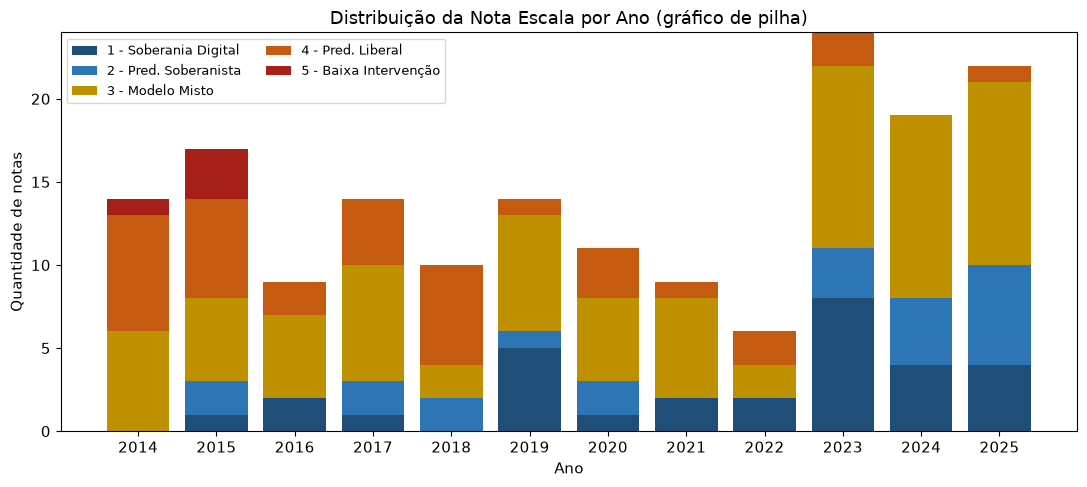

In [9]:
anos = defaultdict(lambda: Counter())
for d in dados:
    dt_obj = parse_data(d["data"])
    if dt_obj is None:
        continue
    anos[dt_obj.year][int(d["Nota_Escala"])] += 1

anos_ord = sorted(anos.keys())
bottom = np.zeros(len(anos_ord))
fig, ax = plt.subplots(figsize=(11, 5))
for k in ORDENS:
    vals = [anos[a].get(k, 0) for a in anos_ord]
    ax.bar([str(a) for a in anos_ord], vals, bottom=bottom, label=ROTULOS[k], color=cores_escala[k-1])
    bottom += np.array(vals)
ax.set_ylabel("Quantidade de notas")
ax.set_xlabel("Ano")
ax.set_title("Distribuição da Nota Escala por Ano (gráfico de pilha)")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## 4. Resumo Numérico

Tabela consolidada com as principais estatísticas para referência.


In [10]:
print("=== Resumo da Escala Ordinal (LLM) ===")
print(f"Total de notas: {len(dados)}")
print()
print("Distribuição da NOTA ESCALA:")
for k in ORDENS:
    c = cont.get(k, 0)
    print(f"  {ROTULOS[k]:28s}: {c:3d} ({100*c/len(dados):.1f}%)")
print()
media_geral = np.mean([int(d["Nota_Escala"]) for d in dados])
print(f"Nota média (geral): {media_geral:.3f}")


=== Resumo da Escala Ordinal (LLM) ===
Total de notas: 169

Distribuição da NOTA ESCALA:
  1 - Soberania Digital       :  30 (17.8%)
  2 - Pred. Soberanista       :  22 (13.0%)
  3 - Modelo Misto            :  78 (46.2%)
  4 - Pred. Liberal           :  35 (20.7%)
  5 - Baixa Intervenção       :   4 (2.4%)

Nota média (geral): 2.769
